In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.colors import LogNorm, SymLogNorm

import sys, os
sys.path.append(os.path.abspath("../src"))

from binomial_model import option_price, option_price_no_volatility
from visualization import plot_binomial_trees
from black_scholes_merton import BSM_pricing
from greeks import delta, theta, gamma, vega, rho

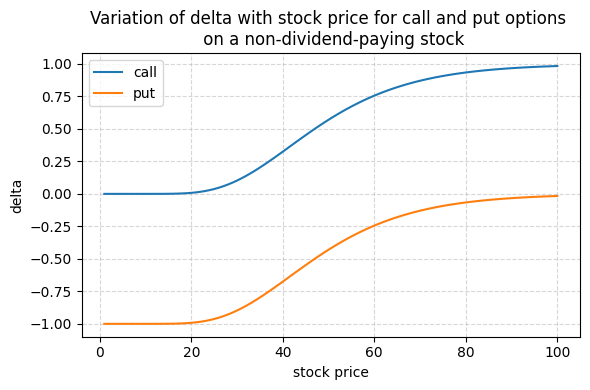

In [32]:
stocks = np.linspace(1,100,100)
k, r, sigma, T = 50, 0, 0.25, 2

deltas_call = delta(option_type='call', s=stocks, k=k, r=r, sigma=sigma, T=T)
deltas_put = delta(option_type='put', s=stocks, k=k, r=r, sigma=sigma, T=T)

plt.figure(figsize=(6,4))
plt.plot(stocks, deltas_call, label='call')
plt.plot(stocks, deltas_put, label='put')
plt.ylabel('delta')
plt.xlabel('stock price')
plt.title('Variation of delta with stock price for call and put options \n on a non-dividend-paying stock')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

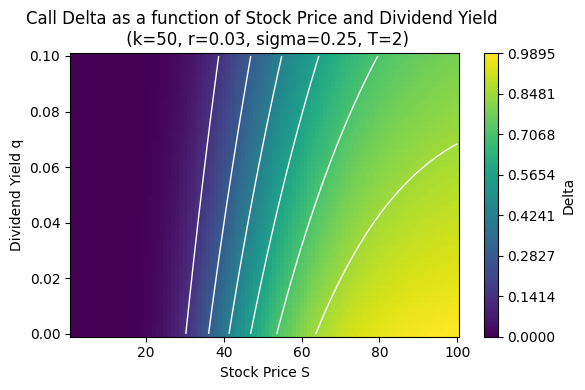

In [40]:
stocks = np.linspace(1, 100, 100)
qs = np.linspace(0, 0.1, 50)
S, Q = np.meshgrid(stocks, qs)

delta_map = delta(option_type='call', s=S, k=50, r=0.03, sigma=0.25, T=2, q=Q)
levels = np.linspace(delta_map.min(), delta_map.max(), 8)

plt.figure(figsize=(6,4))
plt.figure(figsize=(6,4))
pcm = plt.pcolormesh(S, Q, delta_map, shading='auto')
plt.contour(S, Q, delta_map, colors='w', linewidths=1, levels=levels)
plt.colorbar(pcm, label='Delta', ticks=levels)
plt.xlabel('Stock Price S')
plt.ylabel('Dividend Yield q')
plt.title('Call Delta as a function of Stock Price and Dividend Yield \n (k=50, r=0.03, sigma=0.25, T=2)')
plt.tight_layout()
plt.show()

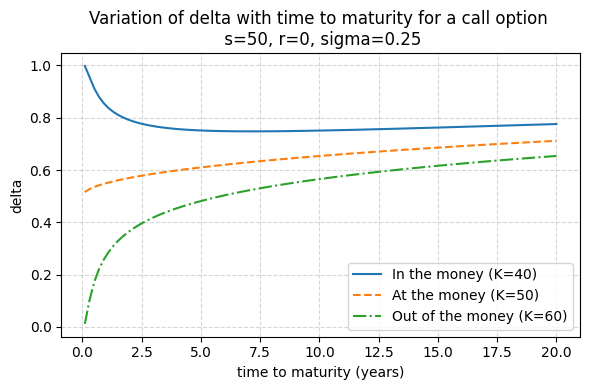

In [34]:
maturities = np.linspace(0.1,20,100)

plt.figure(figsize=(6,4))
for k, moneyness, linestyle in zip(
    [40,50,60],
    ['In the money','At the money','Out of the money'], 
    ['-','--','-.']
):
    deltas_call = delta(option_type='call', s=50, k=k, r=0, sigma=0.25, T=maturities)
    plt.plot(maturities, deltas_call, linestyle=linestyle, label=f'{moneyness} (K={k})')
    
plt.ylabel('delta')
plt.xlabel('time to maturity (years)')
plt.title('Variation of delta with time to maturity for a call option \n s=50, r=0, sigma=0.25')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

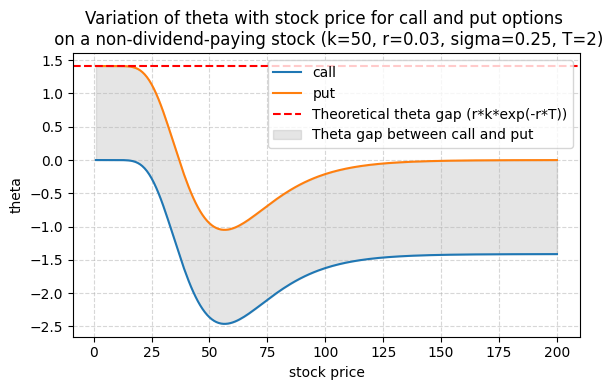

In [35]:
stocks = np.linspace(1,200,200)
k, r, sigma, T = 50, 0.03, 0.25, 2

thetas_call = theta(option_type='call', s=stocks, k=k, r=r, sigma=sigma, T=T)
thetas_put = theta(option_type='put', s=stocks, k=k, r=r, sigma=sigma, T=T)

theta_gap = r*k*np.exp(-r*T)

plt.figure(figsize=(6,4))
plt.plot(stocks, thetas_call, label='call')
plt.plot(stocks, thetas_put, label='put')
plt.axhline(y=theta_gap, color='r', linestyle='--', label='Theoretical theta gap (r*k*exp(-r*T))')
plt.fill_between(stocks, thetas_call, thetas_put, color='grey', alpha=0.2, label='Theta gap between call and put')
plt.ylabel('theta')
plt.xlabel('stock price')
plt.title('Variation of theta with stock price for call and put options \n on a non-dividend-paying stock (k=50, r=0.03, sigma=0.25, T=2)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

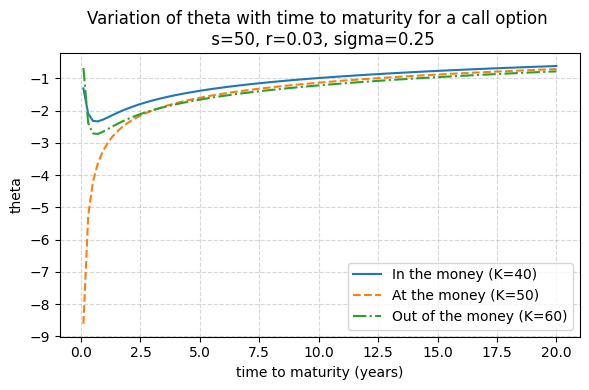

In [36]:
maturities = np.linspace(0.1,20,100)

plt.figure(figsize=(6,4))
for k, moneyness, linestyle in zip(
    [40,50,60],
    ['In the money','At the money','Out of the money'], 
    ['-','--','-.']
):
    thetas_call = theta(option_type='call', s=50, k=k, r=0.03, sigma=0.25, T=maturities)
    plt.plot(maturities, thetas_call, linestyle=linestyle, label=f'{moneyness} (K={k})')
    
plt.ylabel('theta')
plt.xlabel('time to maturity (years)')
plt.title('Variation of theta with time to maturity for a call option \n s=50, r=0.03, sigma=0.25')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

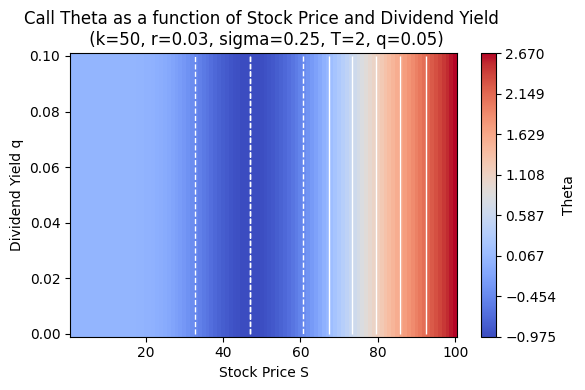

In [145]:
stocks = np.linspace(1, 100, 100)
qs = np.linspace(0, 0.1, 50)
S, Q = np.meshgrid(stocks, qs)

theta_map = theta(option_type='call', s=S, k=50, r=0.03, sigma=0.25, T=2, q=0.05)
levels = np.linspace(theta_map.min(), theta_map.max(), 8)

plt.figure(figsize=(6,4))
pcm = plt.pcolormesh(S, Q, theta_map, shading='auto', cmap='coolwarm')
plt.contour(S, Q, theta_map, colors='w', linewidths=1, levels=levels)
plt.colorbar(pcm, label='Theta', ticks=levels)
plt.xlabel('Stock Price S')
plt.ylabel('Dividend Yield q')
plt.title('Call Theta as a function of Stock Price and Dividend Yield \n (k=50, r=0.03, sigma=0.25, T=2, q=0.05)')
plt.tight_layout()
plt.show()

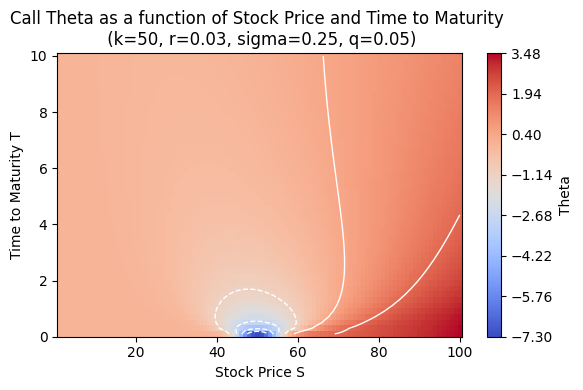

In [42]:
stocks = np.linspace(1, 100, 100)
maturities = np.linspace(0.1, 10,50)
S, M = np.meshgrid(stocks, maturities)

theta_map = theta(option_type='call', s=S, k=50, r=0.03, sigma=0.25, T=M, q=0.05)
levels = np.linspace(theta_map.min(), theta_map.max(), 8)

plt.figure(figsize=(6,4))
pcm = plt.pcolormesh(S, M, theta_map, shading='auto', cmap='coolwarm')
plt.contour(S, M, theta_map, colors='w', linewidths=1, levels=levels)
plt.colorbar(pcm, label='Theta', ticks=levels)
plt.xlabel('Stock Price S')
plt.ylabel('Time to Maturity T')
plt.title('Call Theta as a function of Stock Price and Time to Maturity \n (k=50, r=0.03, sigma=0.25, q=0.05)')
plt.tight_layout()
plt.show()

/var/folders/d_/6y86tpf532z078fl9rsr03b40000gn/T/ipykernel_23603/335352181.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


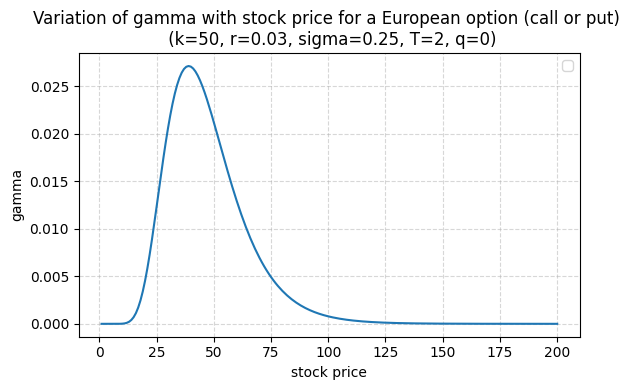

In [61]:
stocks = np.linspace(1,200,200)
k, r, sigma, T, q = 50, 0.03, 0.25, 2, 0

gammas = gamma(s=stocks, k=k, r=r, sigma=sigma, T=T)

plt.figure(figsize=(6,4))
plt.plot(stocks, gammas)
plt.ylabel('gamma')
plt.xlabel('stock price')
plt.title('Variation of gamma with stock price for a European option (call or put) \n (k=50, r=0.03, sigma=0.25, T=2, q=0)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

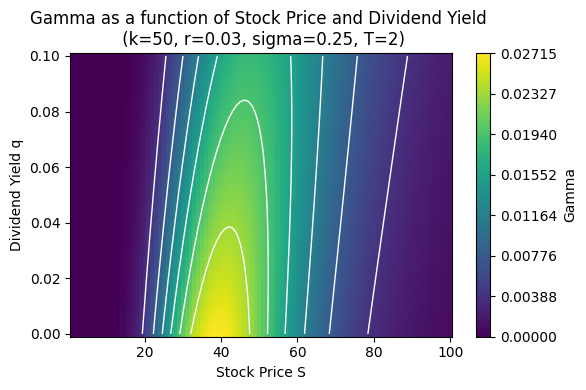

In [10]:
stocks = np.linspace(1, 100, 100)
qs = np.linspace(0, 0.1, 50)
S, Q = np.meshgrid(stocks, qs)

gamma_map = gamma(s=S, k=50, r=0.03, sigma=0.25, T=2, q=Q)
levels = np.linspace(gamma_map.min(), gamma_map.max(), 8)

plt.figure(figsize=(6,4))
pcm = plt.pcolormesh(S, Q, gamma_map, shading='auto', cmap='viridis')
plt.contour(S, Q, gamma_map, colors='w', linewidths=1, levels=levels)
plt.colorbar(pcm, label='Gamma', ticks=levels)
plt.xlabel('Stock Price S')
plt.ylabel('Dividend Yield q')
plt.title('Gamma as a function of Stock Price and Dividend Yield \n (k=50, r=0.03, sigma=0.25, T=2)')
plt.tight_layout() 
plt.show()

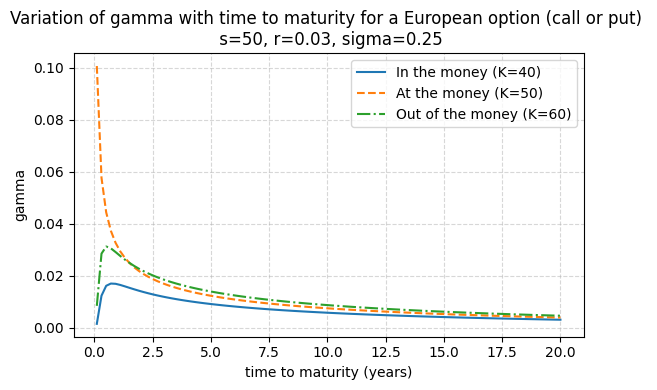

In [46]:
maturities = np.linspace(0.1,20,100)

plt.figure(figsize=(6,4))
for k, moneyness, linestyle in zip(
    [40,50,60],
    ['In the money','At the money','Out of the money'], 
    ['-','--','-.']
):
    gammas = gamma(s=50, k=k, r=0.03, sigma=0.25, T=maturities)
    plt.plot(maturities, gammas, linestyle=linestyle, label=f'{moneyness} (K={k})')
    
plt.ylabel('gamma')
plt.xlabel('time to maturity (years)')
plt.title('Variation of gamma with time to maturity for a European option (call or put) \n s=50, r=0.03, sigma=0.25')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

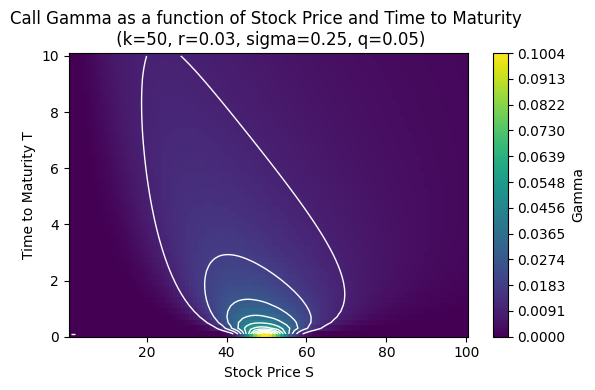

In [47]:
stocks = np.linspace(1, 100, 100)
maturities = np.linspace(0.1, 10,50)
S, M = np.meshgrid(stocks, maturities)

gamma_map = gamma(s=S, k=50, r=0.03, sigma=0.25, T=M, q=0.05)
levels = np.linspace(gamma_map.min(), gamma_map.max(), 12)

plt.figure(figsize=(6,4))
pcm = plt.pcolormesh(S, M, gamma_map, shading='auto', cmap='viridis')
plt.contour(S, M, gamma_map, colors='w', linewidths=1, levels=levels)
plt.colorbar(pcm, label='Gamma', ticks=levels)
plt.xlabel('Stock Price S')
plt.ylabel('Time to Maturity T')
plt.title('Call Gamma as a function of Stock Price and Time to Maturity \n (k=50, r=0.03, sigma=0.25, q=0.05)')
plt.tight_layout() 
plt.show()

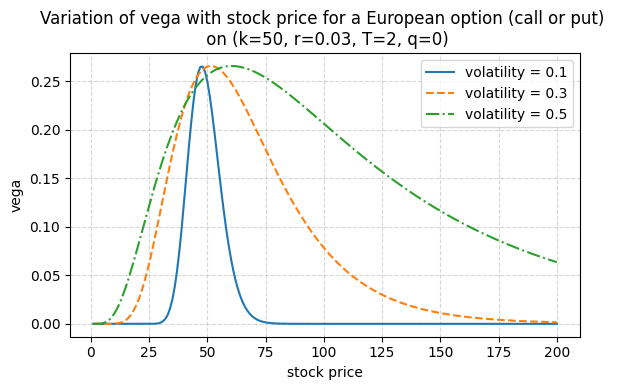

In [48]:
stocks = np.linspace(1,200,200)
k, r, T = 50, 0.03, 2

plt.figure(figsize=(6,4))
for sigma, linestyle in zip(
    [0.1, 0.3, 0.5],
    ['-','--','-.']
):
    vegas = vega(s=stocks, k=k, r=r, sigma=sigma, T=T)
    plt.plot(stocks, vegas, linestyle=linestyle, label=f'volatility = {sigma}')
plt.ylabel('vega')
plt.xlabel('stock price')
plt.title('Variation of vega with stock price for a European option (call or put) \n on (k=50, r=0.03, T=2, q=0)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

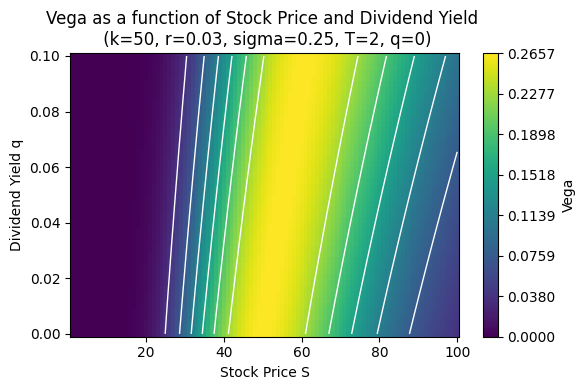

In [49]:
stocks = np.linspace(1, 100, 100)
qs = np.linspace(0, 0.1, 50)
S, Q = np.meshgrid(stocks, qs)

vega_map = vega(s=S, k=50, r=0.03, sigma=0.25, T=2, q=Q)
levels = np.linspace(vega_map.min(), vega_map.max(), 8)

plt.figure(figsize=(6,4))
pcm = plt.pcolormesh(S, Q, vega_map, shading='auto', cmap='viridis')
plt.contour(S, Q, vega_map, colors='w', linewidths=1, levels=levels)
plt.colorbar(pcm, label='Vega', ticks=levels)
plt.xlabel('Stock Price S')
plt.ylabel('Dividend Yield q')
plt.title('Vega as a function of Stock Price and Dividend Yield \n (k=50, r=0.03, sigma=0.25, T=2, q=0)')
plt.tight_layout() 
plt.show()

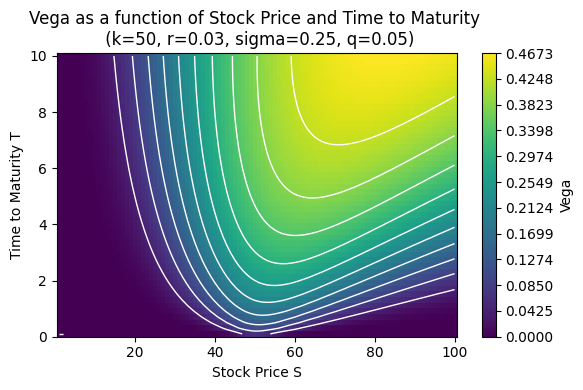

In [50]:
stocks = np.linspace(1, 100, 100)
maturities = np.linspace(0.1, 10,50)
S, M = np.meshgrid(stocks, maturities)

vega_map = vega(s=S, k=50, r=0.03, sigma=0.25, T=M, q=0.05)
levels = np.linspace(vega_map.min(), vega_map.max(), 12)

plt.figure(figsize=(6,4))
pcm = plt.pcolormesh(S, M, vega_map, shading='auto', cmap='viridis')
plt.contour(S, M, vega_map, colors='w', linewidths=1, levels=levels)
plt.colorbar(pcm, label='Vega', ticks=levels)
plt.xlabel('Stock Price S')
plt.ylabel('Time to Maturity T')
plt.title('Vega as a function of Stock Price and Time to Maturity \n (k=50, r=0.03, sigma=0.25, q=0.05)')
plt.tight_layout() 
plt.show()

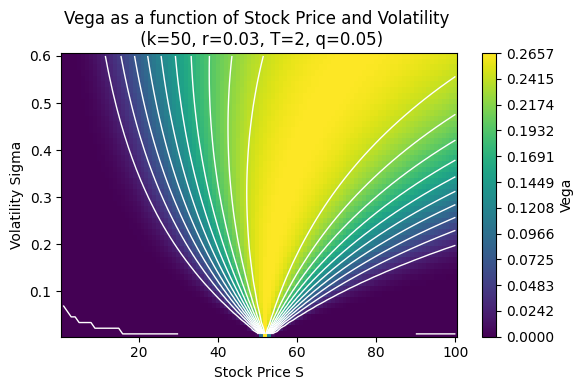

In [51]:
stocks = np.linspace(1, 100, 100)
volatilities = np.linspace(0.01, 0.60,50)
S, V = np.meshgrid(stocks, volatilities)

vega_map = vega(s=S, k=50, r=0.03, sigma=V, T=2, q=0.05)
levels = np.linspace(vega_map.min(), vega_map.max(), 12)

plt.figure(figsize=(6,4))
pcm = plt.pcolormesh(S, V, vega_map, shading='auto', cmap='viridis')
plt.contour(S, V, vega_map, colors='w', linewidths=1, levels=levels)
plt.colorbar(pcm, label='Vega', ticks=levels)
plt.xlabel('Stock Price S')
plt.ylabel('Volatility Sigma')
plt.title('Vega as a function of Stock Price and Volatility \n (k=50, r=0.03, T=2, q=0.05)')
plt.tight_layout() 
plt.show()

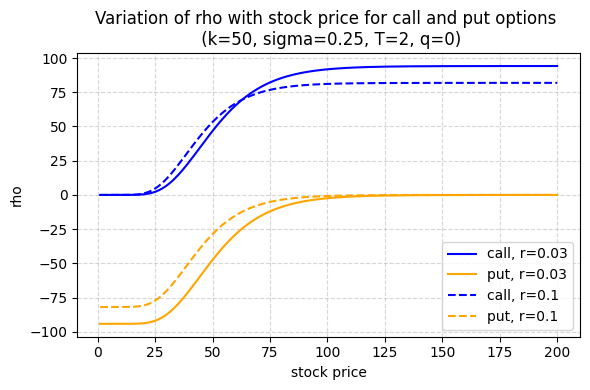

In [52]:
stocks = np.linspace(1,200,200)
k, sigma, T = 50, 0.25, 2

plt.figure(figsize=(6,4))
for r, linestyle in zip([0.03, 0.10], ['-','--']):
    rhos_call = rho(option_type='call', s=stocks, k=k, r=r, sigma=sigma, T=T)
    rhos_put = rho(option_type='put', s=stocks, k=k, r=r, sigma=sigma, T=T)

    plt.plot(stocks, rhos_call, linestyle=linestyle, color='blue', label=f'call, r={r}')
    plt.plot(stocks, rhos_put, linestyle=linestyle, color='orange', label=f'put, r={r}')

plt.ylabel('rho')
plt.xlabel('stock price')
plt.title('Variation of rho with stock price for call and put options \n (k=50, sigma=0.25, T=2, q=0)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

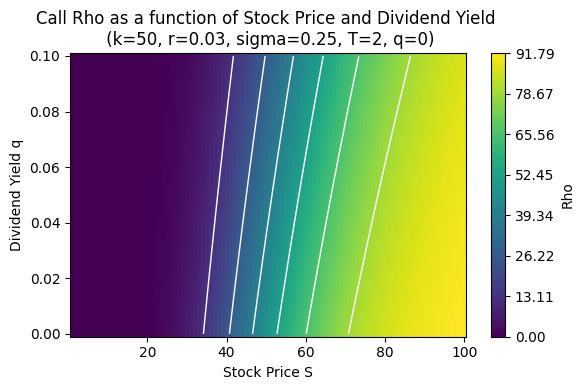

In [55]:
stocks = np.linspace(1, 100, 100)
qs = np.linspace(0, 0.1, 50)
S, Q = np.meshgrid(stocks, qs)

rho_map = rho(option_type='call', s=S, k=50, r=0.03, sigma=0.25, T=2, q=Q)
levels = np.linspace(rho_map.min(), rho_map.max(), 8)

plt.figure(figsize=(6,4))
pcm = plt.pcolormesh(S, Q, rho_map, shading='auto', cmap='viridis')
plt.contour(S, Q, rho_map, colors='w', linewidths=1, levels=levels)
plt.colorbar(pcm, label='Rho', ticks=levels)
plt.xlabel('Stock Price S')
plt.ylabel('Dividend Yield q')
plt.title('Call Rho as a function of Stock Price and Dividend Yield \n (k=50, r=0.03, sigma=0.25, T=2, q=0)')
plt.tight_layout() 
plt.show()

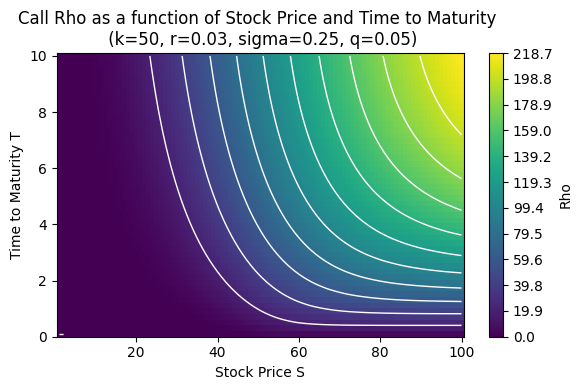

In [58]:
stocks = np.linspace(1, 100, 100)
maturities = np.linspace(0.1, 10,50)
S, M = np.meshgrid(stocks, maturities)

rho_map = rho(option_type='call', s=S, k=50, r=0.03, sigma=0.25, T=M, q=0.05)
levels = np.linspace(rho_map.min(), rho_map.max(), 12)

plt.figure(figsize=(6,4))
pcm = plt.pcolormesh(S, M, rho_map, shading='auto', cmap='viridis')
plt.contour(S, M, rho_map, colors='w', linewidths=1, levels=levels)
plt.colorbar(pcm, label='Rho', ticks=levels)
plt.xlabel('Stock Price S')
plt.ylabel('Time to Maturity T')
plt.title('Call Rho as a function of Stock Price and Time to Maturity \n (k=50, r=0.03, sigma=0.25, q=0.05)')
plt.tight_layout() 
plt.show()

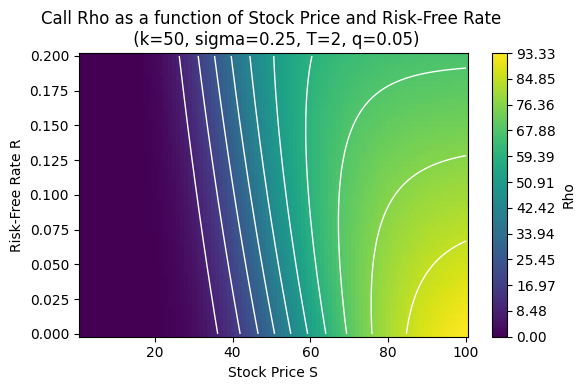

In [60]:
stocks = np.linspace(1, 100, 100)
rates = np.linspace(0.0, 0.2, 50)
S, R = np.meshgrid(stocks, rates)

rho_map = rho(option_type='call', s=S, k=50, r=R, sigma=0.25, T=2, q=0.05)
levels = np.linspace(rho_map.min(), rho_map.max(), 12)

plt.figure(figsize=(6,4))
pcm = plt.pcolormesh(S, R, rho_map, shading='auto', cmap='viridis')
plt.contour(S, R, rho_map, colors='w', linewidths=1, levels=levels)
plt.colorbar(pcm, label='Rho', ticks=levels)
plt.xlabel('Stock Price S')
plt.ylabel('Risk-Free Rate R')
plt.title('Call Rho as a function of Stock Price and Risk-Free Rate \n (k=50, sigma=0.25, T=2, q=0.05)')
plt.tight_layout() 
plt.show()

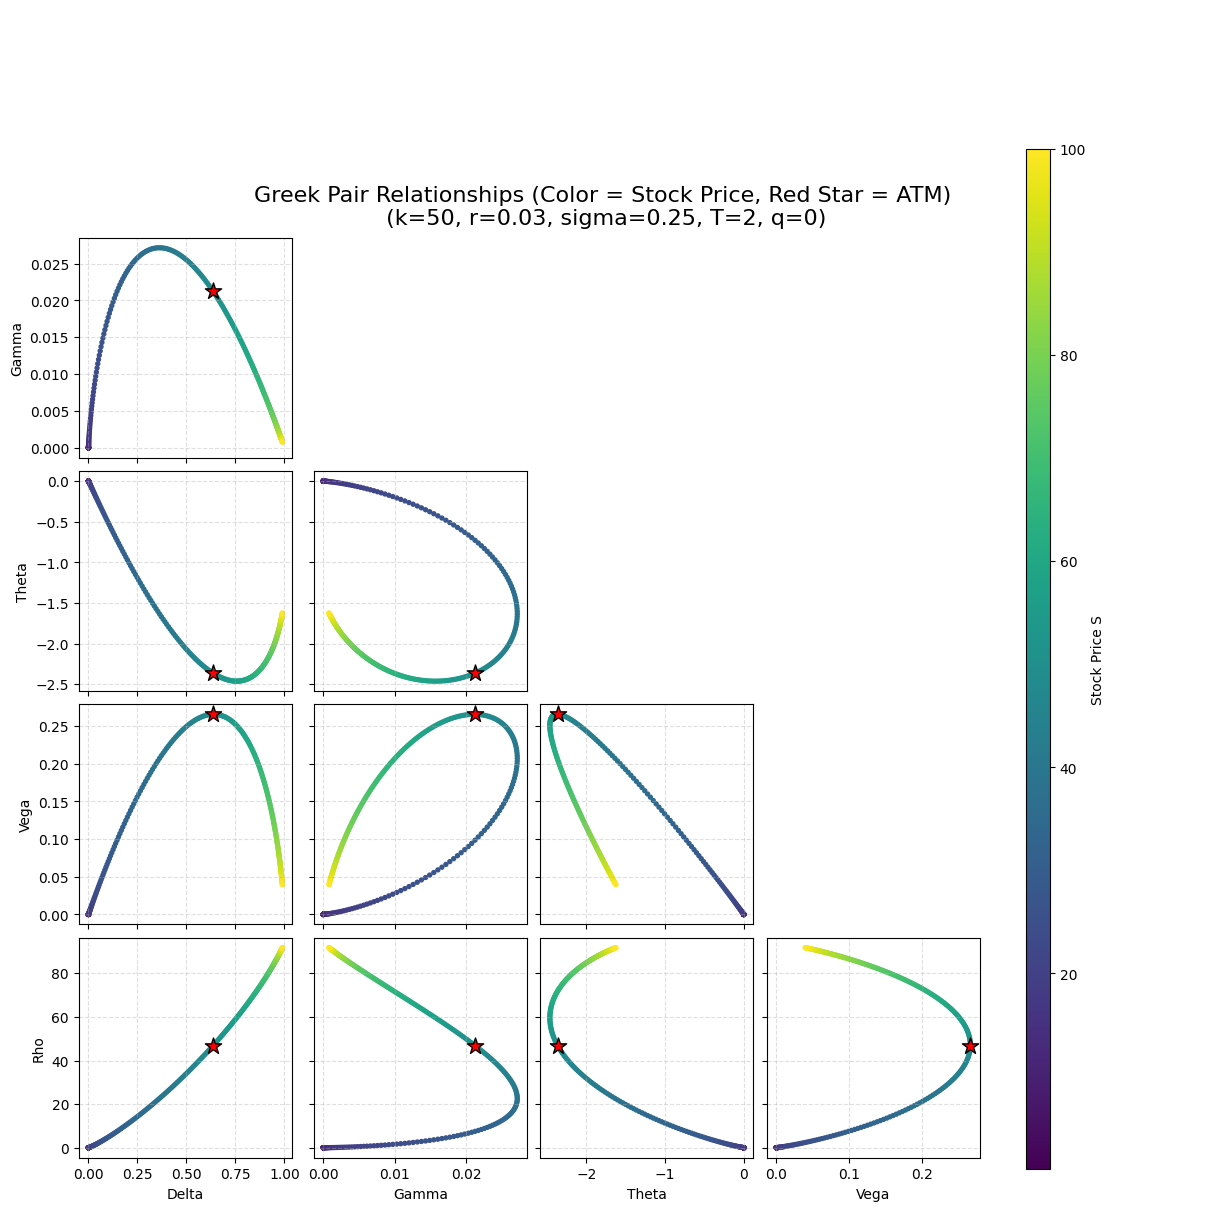

In [98]:
import numpy as np
import matplotlib.pyplot as plt

stocks = np.linspace(1, 100, 300)
k, r, sigma, T, q = 50, 0.03, 0.25, 2, 0

# Compute Greeks
greeks = {
    "Delta": delta(option_type='call', s=stocks, k=k, r=r, sigma=sigma, T=T, q=q),
    "Gamma": gamma(s=stocks, k=k, r=r, sigma=sigma, T=T, q=q),
    "Theta": theta(option_type='call', s=stocks, k=k, r=r, sigma=sigma, T=T, q=q),
    "Vega":  vega(s=stocks, k=k, r=r, sigma=sigma, T=T, q=q),
    "Rho":   rho(option_type='call', s=stocks, k=k, r=r, sigma=sigma, T=T, q=q)
}

names = list(greeks.keys())
n = len(names)

atm_idx = np.argmin(np.abs(stocks - k))

fig, axes = plt.subplots(n, n, figsize=(12, 12), constrained_layout=True)

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        
        if i > j:  # lower triangle only
            x_name = names[j]
            y_name = names[i]
            
            sc = ax.scatter(greeks[x_name], greeks[y_name], c=stocks,
                cmap='viridis', s=8)

            ax.scatter(greeks[x_name][atm_idx], greeks[y_name][atm_idx], 
                       color='red', marker='*', s=150, edgecolor='k', zorder=5)
            
            ax.grid(True, linestyle='--', alpha=0.4)
            
            if i == n - 1:
                ax.set_xlabel(x_name)
            else:
                ax.set_xticklabels([])
                
            if j == 0:
                ax.set_ylabel(y_name)
            else:
                ax.set_yticklabels([])
                
        else:
            ax.axis("off")


cbar_ax = fig.add_axes([0.85, 0.03, 0.02, 0.85]) 
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("Stock Price S")

fig.suptitle( "Greek Pair Relationships (Color = Stock Price, Red Star = ATM) \n (k=50, r=0.03, sigma=0.25, T=2, q=0) ", 
            fontsize=16, y=0.85)

plt.show()

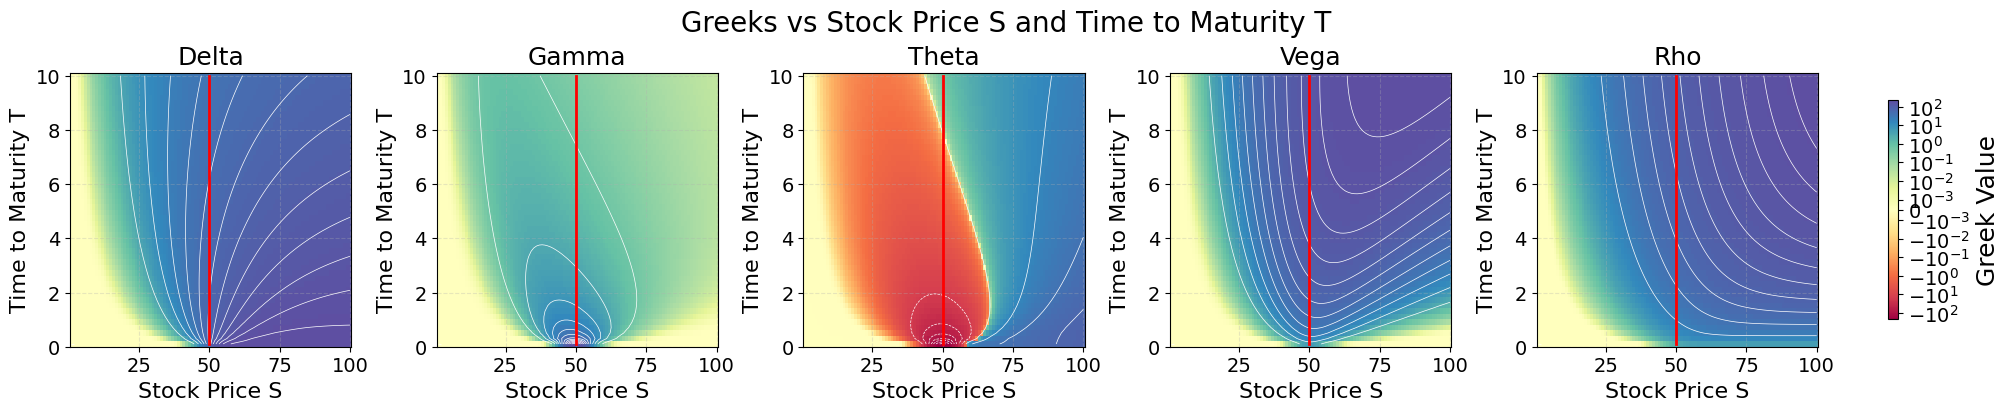

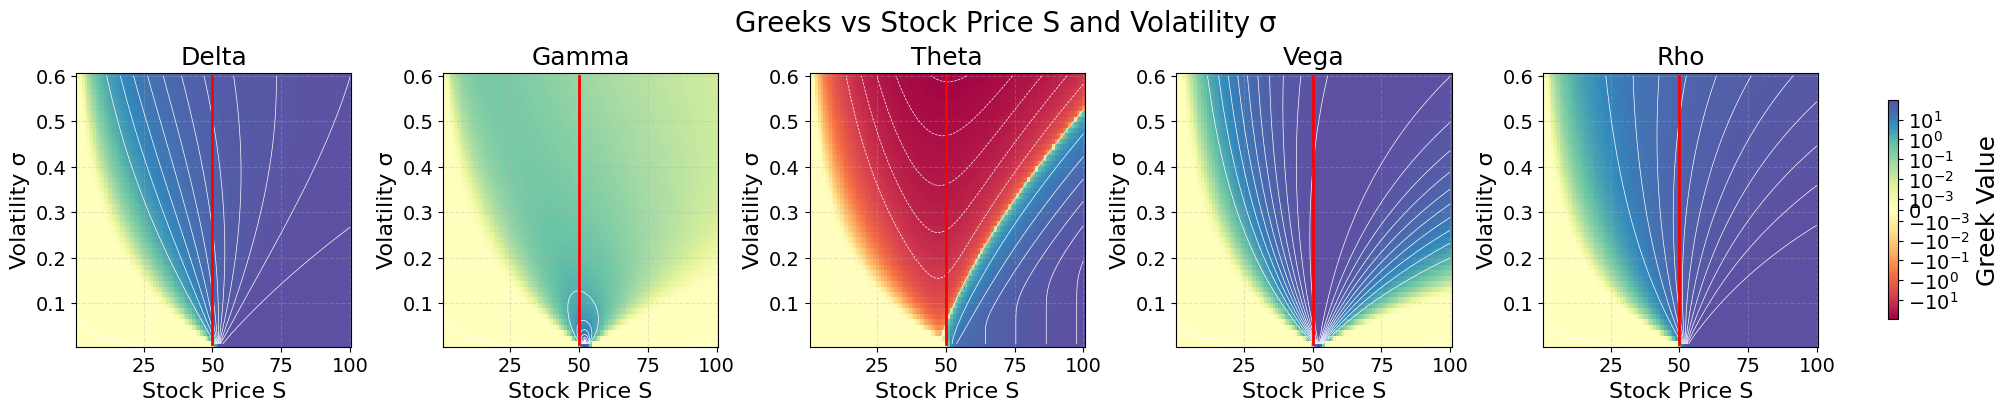

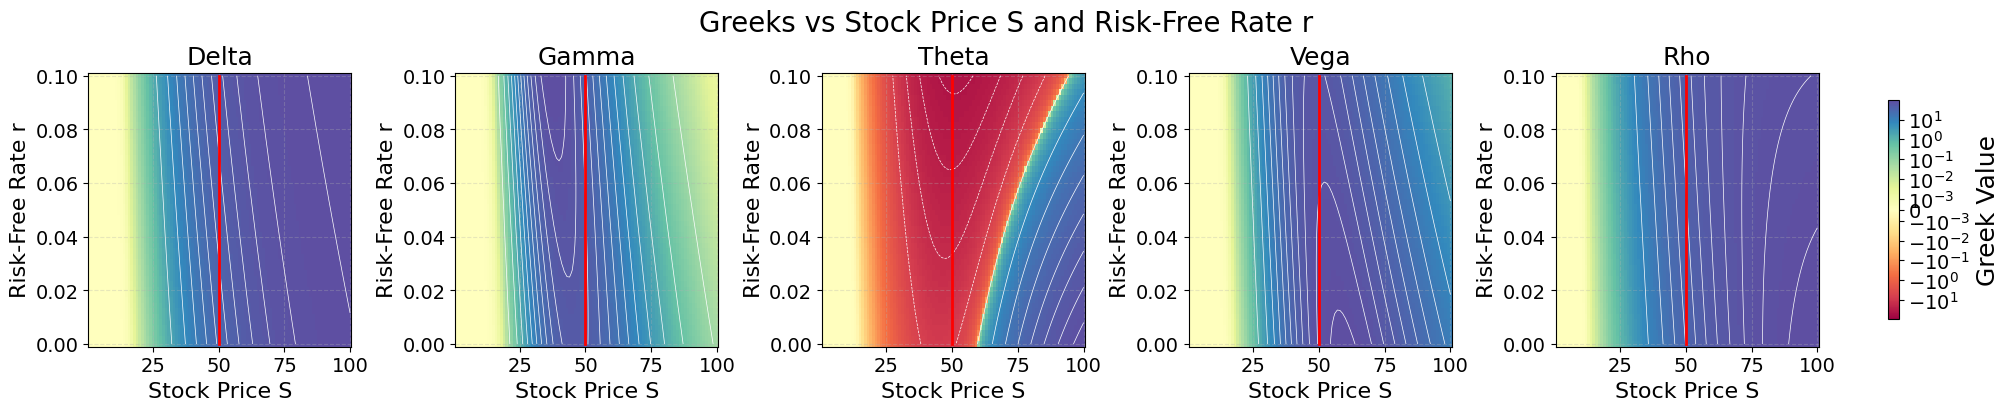

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

# Parameters
stocks = np.linspace(1, 100, 100)
maturities = np.linspace(0.1, 10, 50)
volatilities = np.linspace(0.01, 0.6, 50)
rates = np.linspace(0.0, 0.1, 50)
k, q = 50, 0.05
sigma, r = 0.25, 0.03

# Define parameter pairs
param_pairs = [
    (stocks, maturities, 'Stock Price S', 'Time to Maturity T'),
    (stocks, volatilities, 'Stock Price S', 'Volatility σ'),
    (stocks, rates, 'Stock Price S', 'Risk-Free Rate r')
]

# Greek functions
greek_funcs = {
    'Delta': lambda s, T_var=None, sigma_var=None, r_var=None: delta(option_type='call', s=s, k=k, r=r_var if r_var is not None else r, sigma=sigma_var if sigma_var is not None else sigma, T=T_var if T_var is not None else 2, q=q),
    'Gamma': lambda s, T_var=None, sigma_var=None, r_var=None: gamma(s=s, k=k, r=r_var if r_var is not None else r, sigma=sigma_var if sigma_var is not None else sigma, T=T_var if T_var is not None else 2, q=q),
    'Theta': lambda s, T_var=None, sigma_var=None, r_var=None: theta(option_type='call', s=s, k=k, r=r_var if r_var is not None else r, sigma=sigma_var if sigma_var is not None else sigma, T=T_var if T_var is not None else 2, q=q),
    'Vega':  lambda s, T_var=None, sigma_var=None, r_var=None: vega(s=s, k=k, r=r_var if r_var is not None else r, sigma=sigma_var if sigma_var is not None else sigma, T=T_var if T_var is not None else 2, q=q),
    'Rho':   lambda s, T_var=None, sigma_var=None, r_var=None: rho(option_type='call', s=s, k=k, r=r_var if r_var is not None else r, sigma=sigma_var if sigma_var is not None else sigma, T=T_var if T_var is not None else 2, q=q)
}
# Loop over parameter pairs
for x_vals, y_vals, x_label, y_label in param_pairs:
    X, Y = np.meshgrid(x_vals, y_vals)

    # Compute all Greeks for this parameter pair
    greeks_data = {}
    for name, func in greek_funcs.items():
        if x_label == 'Stock Price S' and y_label == 'Time to Maturity T':
            greeks_data[name] = func(s=X, T_var=Y)
        elif x_label == 'Stock Price S' and y_label == 'Volatility σ':
            greeks_data[name] = func(s=X, sigma_var=Y)
        elif x_label == 'Stock Price S' and y_label == 'Risk-Free Rate r':
            greeks_data[name] = func(s=X, r_var=Y)

    # Create figure with 5 panels for Greeks
    fig, axes = plt.subplots(1, 5, figsize=(20,4), constrained_layout=True)
    fig.suptitle(f"Greeks vs {x_label} and {y_label}", fontsize=20)

    for ax, (g_name, Z) in zip(axes, greeks_data.items()):
        # SymLogNorm with per-Greek symmetric color limits
        abs_max = max(abs(Z.min()), abs(Z.max()))
        linthresh = 1e-3  # small linear region around zero
        pcm = ax.pcolormesh(
            X, Y, Z,
            cmap='Spectral',#'RdBu_r',
            shading='auto',
            norm=SymLogNorm(linthresh=linthresh, linscale=0.5, vmin=-abs_max, vmax=abs_max)
        )

        # Add contour lines
        ax.contour(X, Y, Z, colors='w', linewidths=0.5, levels=12)
        ax.set_title(g_name, fontsize=18)
        ax.set_xlabel(x_label, fontsize=16)
        ax.set_ylabel(y_label, fontsize=16)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.tick_params(labelsize=14)

        # ATM marker (S = K)
        atm_idx = np.argmin(np.abs(x_vals - k))
        ax.plot(x_vals[atm_idx]*np.ones_like(y_vals), y_vals, 'r', lw=2)

    # Shared colorbar
    cbar = fig.colorbar(pcm, ax=axes.ravel().tolist(), location='right', shrink=0.8, pad=0.03)
    cbar.set_label('Greek Value', fontsize=18)
    cbar.ax.tick_params(labelsize=14)

    plt.show()